# 03 — Popularity Modeling

**Spotify Content Performance Analytics** — Phase 3 interpretable modeling layer.

## 1. Analytical question

> How much variation in `popularity_score` is associated with observable
> track/content/context characteristics, and how much additional predictive
> power appears when `artist_1_pop` is included?

**This is an observational dataset. No causal claims are made anywhere in
this notebook.** The goal is a defensible analytical comparison between a
content/context model (Model A) and a content/context + artist-popularity
model (Model B) — not a flashy model or maximum R².

Phase 2 (data foundation, cleaning, SQL layer) is frozen and unmodified by
this notebook; it only reads the already-built primary/sensitivity Parquet
files.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from src import modeling as M

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
FIGURES_DIR = "../figures"

## 2. Modeling sample

Built from the PRIMARY analytical dataset (Phase 2) via
`src/modeling.build_modeling_frame()`. Never modifies the frozen Phase 2
pipeline — only reads its Parquet output.

In [2]:
primary = pd.read_parquet("../data/processed/primary.parquet")
modeling_df, sample_notes = M.build_modeling_frame(primary)
sample_notes

{'input_rows': 277937,
 'rows_dropped_missing_release_decade': 4,
 'tempo_values_treated_as_missing': 90,
 'rows_with_unknown_genre': 167547,
 'output_rows': 277933,
 'rows_missing_artist_1': 19,
 'rows_with_placeholder_artist_1': 14855}

**Sample construction notes:**
- 4 rows with unknown `release_decade_clean` are dropped from the MODELING
  sample only (they remain in the primary analytical dataset untouched).
- 90 rows with `tempo == 0` are treated as missing (Phase 2 policy) and
  median-imputed inside the pipeline, fit on training data only.
- 167,547 rows (60.3%) have no observed primary genre and are coded as an
  explicit `"Unknown"` category, not imputed or dropped.
- 19 rows have a missing `artist_1`, and 14,855 rows carry a placeholder
  `artist_1` label that does not name a single artist (see §4) — both cases
  are handled explicitly in how grouping keys are built, not in this table.

## 3. Feature definitions

**Target:** `popularity_score` (0–100). Never included as a feature.
`popularity`, `popularity_tier`, and `is_high_popularity` are excluded from
every model because they are derived directly (in `popularity`'s case,
*exactly* — see Phase 2 §16) from the target.

**Model A (content / context):**
| Feature | Type | What it represents | Caveat |
|---|---|---|---|
| `loudness` | continuous | Spotify-measured overall loudness (dB) | none beyond dataset scope |
| `valence` | continuous | Spotify's musical-positivity measure (0–1) | none beyond dataset scope |
| `tempo` | continuous | Beats per minute | 90 zero-tempo rows treated as missing, imputed |
| `track_duration_minutes` | continuous | Derived from `duration_ms` | none |
| `album_type` | categorical | album / single / compilation | none beyond dataset scope |
| `artist_1_genre_1` (+ `Unknown`) | categorical | Primary genre, each observed genre its own level | genre availability is NOT random w.r.t. popularity (Phase 2 §15) |
| `release_decade_clean` | categorical | Release decade | **entangled with recency, survivorship, catalog composition — not a pure content attribute** |

**Model B = Model A + `artist_1_pop`.** `artist_1_pop` is conceptually very
close to the outcome — popular artists mechanically tend to have popular
tracks via correlated underlying algorithmic signals. Model B is a
**contextual/predictive comparison, not evidence of a causal artist-
popularity effect**.

Genre is **not** collapsed to top-N/Other: all 17 observed genres are used
as their own level, plus an explicit `Unknown` level.

**Preprocessing:** continuous features are median-imputed and standardized;
categorical features are one-hot encoded with `categories="auto"` —
meaning the encoder's vocabulary (which category names exist at all) is
learned **strictly from the training split** inside `pipeline.fit()`, never
from the full dataset or the held-out test rows. The dropped reference
category per feature (`album_type`→`album`, genre→`Unknown`,
decade→`2010`) is fixed a priori from the overall dataset's composition —
a constant of the analysis design, not re-derived per split — and
`handle_unknown="ignore"` safely encodes any category that turns out to
exist only in a given test split as all-zeros, rather than requiring it to
be known in advance.

## 4. Split design

**Primary generalization evidence: a repeated artist-grouped split**
(`GroupShuffleSplit`, 10 pre-declared seeds — see §6). Recognized
named-artist groups are held out across train/test; unidentified or
placeholder credits are assigned individual synthetic groups, so
underlying performer overlap cannot be ruled out for those rows (see
"Grouping key" below). **Secondary: a conventional reproducible random row
split**, answering a different practical question (§7).

### Grouping key

`artist_1` is a useful approximate artist identifier, but this dataset
contains labels that do not name one canonical artist:

In [3]:
placeholder_check = pd.Series(M.PLACEHOLDER_ARTIST_LABELS, name="label").to_frame()
placeholder_check["n_rows_in_dataset"] = [
    (modeling_df["artist_1"] == label).sum() for label in M.PLACEHOLDER_ARTIST_LABELS
]
placeholder_check

,label,n_rows_in_dataset
0,Various Artists,14840
1,Original Cast,8
2,Unknown,4
3,Unknown Artist,3


These were identified by inspecting the label TEXT for an exact,
anchored match to a placeholder-style pattern (e.g. `"^various artists?$"`,
`"^unknown( artist)?$"`, `"^original cast$"`) — never inferred from
frequency alone (many genuine artists are also high-frequency, e.g.
"Taylor Swift" at 241 rows in this dataset). `"Various Artists"` is a
standard compilation-album credit covering many unrelated performers;
`"Original Cast"` is a cast-recording credit, not a named performer or
group; `"Unknown"` / `"Unknown Artist"` are explicit placeholders for
unidentified artist information. No other label matched.

**Grouping rule:** a normal, named `artist_1` value groups those rows
together (so real artists with multiple tracks stay on one side of the
split); a missing `artist_1`, or one of the labels above, gives EACH row
its own unique synthetic group — there is no basis to treat two
"Various Artists" rows, or two rows with a missing artist, as the same
artist.

In [4]:
group_size = M.group_size_summary(modeling_df)
group_size

{'n_groups': 105152,
 'median_group_size': 1.0,
 'p90_group_size': 5.0,
 'p99_group_size': 28.0,
 'ten_largest_group_sizes': [267, 241, 237, 234, 221, 217, 213, 212, 197, 185],
 'largest_group_pct_of_rows': 0.096,
 'total_rows': 277933}

**Group-size structure after this correction:** 105,152 groups total;
median size 1 (most artists have exactly one track in this dataset); the
90th/99th percentile sizes are 5/28; the ten largest real-artist groups
range from 185–267 tracks; and the single largest group is **0.10% of the
dataset** — a very different picture from treating "Various Artists" as one
14,840-row group (5.3% of the dataset), which would have let one label
dominate whichever side of a held-out split it happened to land on.
Because no remaining group is large enough to dominate a fold this way, a
single giant group swinging the result the way "Various Artists" once did
is no longer possible — see §6 for how much (modest) seed-to-seed variation
remains regardless.

## 5. Baseline, Model A, Model B — illustrative single split (seed 42)

A single split is shown here for illustration and to walk through the
model-fitting mechanics; §6's repeated 10-seed sweep is the primary
generalization evidence, not this one split.

In [5]:
g_train_idx, g_test_idx = M.grouped_split(modeling_df, random_state=42)

baseline_g = M.run_baseline(modeling_df, g_train_idx, g_test_idx)
model_a_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, g_train_idx, g_test_idx)
model_b_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, g_train_idx, g_test_idx)

results_grouped = pd.DataFrame({
    "baseline": baseline_g["metrics"],
    "Model A": model_a_g["metrics"],
    "Model B": model_b_g["metrics"],
}).T
results_grouped

,n,r2,mae,rmse
baseline,56344.0,-8.971256e-07,17.844125,20.902667
Model A,56344.0,1.215600e-01,16.505024,19.591043
Model B,56344.0,2.825327e-01,14.275554,17.705270


On this illustrative split, both models beat the baseline, and Model B
clearly outperforms Model A (R² ≈ 0.28 vs. ≈ 0.12). §6 checks whether this
holds up across independently chosen seeds.

## 6. Repeated grouped-split evaluation (primary generalization evidence)

Run across 10 fixed, pre-declared seeds — `[1, 7, 21, 42, 73, 101, 202,
314, 512, 999]` — chosen before looking at any result and never adjusted
afterward.

In [6]:
sweep = M.grouped_split_sweep(modeling_df)
sweep.round(4)

,seed,n_train,n_test,n_train_groups,n_test_groups,test_mean_popularity,baseline_r2,baseline_mae,baseline_rmse,model_a_r2,model_a_mae,model_a_rmse,model_b_r2,model_b_mae,model_b_rmse
0,1,222098,55835,84121,21031,27.7926,-0.0000,18.0434,21.0325,0.1055,16.8161,19.8916,0.2832,14.4448,17.8069
1,7,222607,55326,84121,21031,28.2324,-0.0007,17.6654,20.7480,0.1202,16.3588,19.4545,0.2921,14.0867,17.4511
2,21,222597,55336,84121,21031,27.9066,-0.0000,17.8877,20.9275,0.1246,16.5073,19.5798,0.3000,14.1305,17.5086
3,42,221589,56344,84121,21031,27.8128,-0.0000,17.8441,20.9027,0.1216,16.5050,19.5910,0.2825,14.2756,17.7053
4,73,221872,56061,84121,21031,27.7188,-0.0000,17.7916,20.8433,0.1220,16.4301,19.5300,0.2741,14.3508,17.7581
5,101,223513,54420,84121,21031,27.7684,-0.0000,18.0232,21.0354,0.1266,16.5913,19.6589,0.2939,14.3243,17.6762
6,202,221531,56402,84121,21031,28.0071,-0.0002,17.9208,21.0272,0.1219,16.6223,19.7021,0.2825,14.4134,17.8096
7,314,221853,56080,84121,21031,27.7702,-0.0000,17.7077,20.7396,0.1205,16.4015,19.4498,0.2910,14.0939,17.4631
8,512,222307,55626,84121,21031,27.8046,-0.0000,17.7311,20.7962,0.1225,16.4303,19.4812,0.2997,14.0730,17.4032
9,999,221402,56531,84121,21031,27.9623,-0.0001,17.8759,20.8942,0.1232,16.5407,19.5641,0.2885,14.2567,17.6233


In [7]:
sweep_summary = M.summarize_sweep(sweep)
sweep_summary

,median_r2,min_r2,max_r2,median_mae,median_rmse,n_test_min,n_test_max,n_test_groups_min,n_test_groups_max,test_mean_popularity_min,test_mean_popularity_max
model_a,0.121975,0.105545,0.126588,16.506152,19.571956,NaN,NaN,NaN,NaN,NaN,NaN
model_b,0.289761,0.274111,0.300014,14.266148,17.649710,NaN,NaN,NaN,NaN,NaN,NaN
split_composition,NaN,NaN,NaN,NaN,NaN,54420.0,56531.0,21031.0,21031.0,27.718788,28.23244


**Model A is consistently modest and stable:** R² ranges 0.106–0.127
across all 10 seeds (median ≈0.122) — never beats the baseline by a large
margin, never collapses either. **Model B consistently outperforms Model A
on every single seed:** R² ranges 0.274–0.300 (median ≈0.290). Both ranges
are narrow relative to their central values. Performance varies modestly
across the 10 holdouts. Test-set size, held-out group count, and mean
popularity are relatively stable across seeds (test size 54,420–56,531
rows; 21,031 held-out groups on every seed — `GroupShuffleSplit` applies
the same fixed test fraction to the same total group count regardless of
seed; test-set mean popularity 27.72–28.23), but this analysis does not
isolate the source of the remaining score variation — the model
specification, preprocessing, and feature set are identical across all 10
runs, but distinguishing test-fold composition effects from any other
source of run-to-run difference was not attempted here.

## 7. Random split — a different use case, not a different verdict

A conventional random row split answers a different practical question than
the grouped split, not a "more correct" or "less correct" one:

- **Random row split** approximately asks: *how well can the model predict
  another track when artists represented in the test set may already have
  other tracks represented in training?* This may be relevant to a platform
  analyzing an existing catalog where known artists already have historical
  observations.
- **Artist-grouped split** approximately asks: *how well can the model
  predict tracks credited to a different recognized named-artist group than
  any in training?* This is not a clean test of generalization to
  brand-new artists with no established popularity history: recognized
  named-artist groups are held out across train/test, but unidentified or
  placeholder credits (§4) are each assigned their own synthetic group, so
  underlying performer overlap cannot be ruled out for those rows
  specifically.

Neither is universally superior — the appropriate one depends on the
intended use case.

In [8]:
r_train_idx, r_test_idx = M.random_split(modeling_df, random_state=42)
baseline_r = M.run_baseline(modeling_df, r_train_idx, r_test_idx)
model_a_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, r_train_idx, r_test_idx)
model_b_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, r_train_idx, r_test_idx)

results_random = pd.DataFrame({
    "baseline": baseline_r["metrics"],
    "Model A": model_a_r["metrics"],
    "Model B": model_b_r["metrics"],
}).T
results_random

,n,r2,mae,rmse
baseline,55587.0,-0.000025,17.884354,20.903644
Model A,55587.0,0.115264,16.600511,19.661807
Model B,55587.0,0.275521,14.368688,17.792189


In [9]:
split_comparison = pd.DataFrame({
    "grouped_median_R2": [sweep["model_a_r2"].median(), sweep["model_b_r2"].median()],
    "grouped_seed42_R2": [model_a_g["metrics"]["r2"], model_b_g["metrics"]["r2"]],
    "random_seed42_R2":  [model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]],
}, index=["Model A", "Model B"])
split_comparison

,grouped_median_R2,grouped_seed42_R2,random_seed42_R2
Model A,0.121975,0.121560,0.115264
Model B,0.289761,0.282533,0.275521


**Observed metric difference:** Model A's R² is close under both
designs (grouped median ≈0.122 vs. random ≈0.115). Model B's R² is also
close under both designs (grouped median ≈0.290 vs. random ≈0.276) — Model
B repeatedly outperforms Model A under both evaluation designs.

**Structural reason the settings differ, in principle:** the random split
allows information associated with the same artist identity to appear
across train and test (an artist's other tracks may already be in
training), while the grouped split holds out recognized named-artist
groups. Model B's usefulness in principle depends on which of these two
situations a real deployment resembles, because `artist_1_pop` is an
artist-level/contextual feature.

**What the data shows in THIS case:** that structural difference does not
produce a large observed gap here — both designs point to the same
conclusion. This analysis does not isolate which mechanism, if any,
explains the small remaining gap between the two designs (see §8 for one
concrete, identified contributor).

## 8. `"Various Artists"` — inspection and an excluded-from-evaluation diagnostic

Before the grouping-key fix in §4, all 14,840 `"Various Artists"` rows
could land entirely on one side of a single grouped split, and that (not a
property of the random split) drove an earlier, larger apparent gap between
random and grouped evaluation. This section inspects that label directly
and quantifies how much it still affects the CORRECTED evaluation.

In [10]:
va_pop = modeling_df.loc[modeling_df["artist_1"] == "Various Artists", "artist_1_pop"]
va_target = modeling_df.loc[modeling_df["artist_1"] == "Various Artists", M.TARGET]

print("artist_1_pop for \'Various Artists\' rows:")
print(f"  n={len(va_pop)}, unique values={va_pop.nunique()}, "
      f"min={va_pop.min()}, max={va_pop.max()}, mean={va_pop.mean():.4f}, "
      f"median={va_pop.median()}, std={va_pop.std():.4f}")
print(f"  most common value(s): {va_pop.value_counts().head(3).to_dict()}")
print()
print("actual popularity_score for the SAME rows (for contrast):")
print(f"  mean={va_target.mean():.2f}, median={va_target.median()}, "
      f"std={va_target.std():.2f}, max={va_target.max()}")

artist_1_pop for 'Various Artists' rows:
  n=14840, unique values=1, min=0.0, max=0.0, mean=0.0000, median=0.0, std=0.0000
  most common value(s): {0.0: 14840}

actual popularity_score for the SAME rows (for contrast):
  mean=16.25, median=8.0, std=18.57, max=81.0


`artist_1_pop` is **exactly constant (0.0) for all 14,840 `"Various
Artists"` rows**, while their actual `popularity_score` varies
substantially (mean ≈16, std ≈19, up to 81). This confirms directly, not
just by inference, that `artist_1_pop` does not represent the actual
underlying performers for these compilation tracks and provides little or
misleading information for this subset specifically. This does not tell us
how Spotify computed the value for this label — only that it carries
little information here.

In [11]:
va_test_mask = (modeling_df.iloc[g_test_idx]["artist_1"].reset_index(drop=True) == "Various Artists").to_numpy()
print(f"\'Various Artists\' share of the seed-42 grouped test set: {va_test_mask.mean()*100:.2f}%")
print()
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    full = res["metrics"]
    excl = M.evaluate_predictions(res["y_test"][~va_test_mask], res["y_pred"][~va_test_mask])
    print(f"{name}: R2 full test={full['r2']:.4f}  R2 excluding \'Various Artists\'={excl['r2']:.4f}  "
          f"(diagnostic only -- \'Various Artists\' rows assigned to test remain IN the test set for every headline metric in this notebook)")

'Various Artists' share of the seed-42 grouped test set: 5.28%

Model A: R2 full test=0.1216  R2 excluding 'Various Artists'=0.1089  (diagnostic only -- 'Various Artists' rows assigned to test remain IN the test set for every headline metric in this notebook)
Model B: R2 full test=0.2825  R2 excluding 'Various Artists'=0.2867  (diagnostic only -- 'Various Artists' rows assigned to test remain IN the test set for every headline metric in this notebook)


With the corrected grouping key, excluding `"Various Artists"` from
evaluation changes each model's R² by only a few hundredths — a small,
ordinary-sized effect, not the dominant driver it was before §4's fix. This
is reported as a diagnostic only: these rows remain in whichever split they
were assigned to (train or test) for every headline metric in this
notebook; they are excluded ONLY in the two numbers just shown, to quantify
their residual influence.

## 9. Bounded-prediction diagnostic

`popularity_score` is bounded [0, 100]; the linear models are not.
Reported on RAW, unclipped predictions across all 10 grouped seeds.

In [12]:
bounded_rows = []
for seed in M.GROUPED_SPLIT_SEEDS:
    train_idx, test_idx = M.grouped_split(modeling_df, random_state=seed)
    a = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, train_idx, test_idx)
    b = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, train_idx, test_idx)
    bounded_rows.append({
        "seed": seed,
        "A_pct_below_0": a["bounded"]["pct_below_0"], "A_max_pred": a["bounded"]["max_prediction"],
        "B_pct_below_0": b["bounded"]["pct_below_0"], "B_max_pred": b["bounded"]["max_prediction"],
    })
bounded_sweep = pd.DataFrame(bounded_rows)
bounded_sweep

,seed,A_pct_below_0,A_max_pred,B_pct_below_0,B_max_pred
0,1,0.054,46.732759,0.057,61.997014
1,7,0.027,46.196789,0.065,61.454872
2,21,0.023,46.192996,0.112,62.852691
3,42,0.028,46.735680,0.039,63.217861
4,73,0.021,46.642948,0.082,61.477249
5,101,0.018,46.035544,0.088,58.831752
6,202,0.055,46.063380,0.145,63.006589
7,314,0.034,46.177832,0.045,62.656862
8,512,0.061,46.166800,0.137,62.385061
9,999,0.011,46.315344,0.126,59.723145


Out-of-range predictions are rare and stable for both models (Model A:
0.011%–0.061% below 0; Model B: 0.039%–0.145% below 0; **neither model ever
predicts above 100, on any seed**).

## 10. Target-range compression

Across every seed, Model A's maximum raw prediction stays in the mid-40s
and Model B's stays in the high-50s/low-60s, despite `popularity_score`
ranging 0–100 in this dataset. This section quantifies that compression
directly, using the illustrative seed-42 split from §5.

In [13]:
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    y_true, y_pred = res["y_test"], res["y_pred"]
    print(f"{name}: prediction min={y_pred.min():.2f} max={y_pred.max():.2f} std={y_pred.std():.2f}  |  "
          f"actual min={y_true.min():.2f} max={y_true.max():.2f} std={y_true.std():.2f}")

Model A: prediction min=-13.74 max=46.74 std=7.23  |  actual min=0.00 max=100.00 std=20.90
Model B: prediction min=-7.01 max=63.22 std=11.22  |  actual min=0.00 max=100.00 std=20.90


In [14]:
def tier(x):
    return "low (0-33)" if x <= 33 else ("moderate (34-66)" if x <= 66 else "high (67-100)")

compression_rows = []
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    df = pd.DataFrame({"y_true": res["y_test"], "y_pred": res["y_pred"]})
    df["tier"] = df["y_true"].apply(tier)
    g = df.groupby("tier").apply(lambda d: pd.Series({
        "n": len(d),
        "mae": (d["y_true"] - d["y_pred"]).abs().mean(),
        "mean_prediction": d["y_pred"].mean(),
        "mean_actual": d["y_true"].mean(),
    }), include_groups=False)
    g.insert(0, "model", name)
    compression_rows.append(g)
compression_table = pd.concat(compression_rows).loc[["low (0-33)", "moderate (34-66)", "high (67-100)"]]
compression_table

,model,n,mae,mean_prediction,mean_actual
tier,,,,,
low (0-33),Model A,32904.0,14.925858,25.972807,12.984987
low (0-33),Model B,32904.0,13.675273,23.589466,12.984987
moderate (34-66),Model A,21772.0,17.257281,29.857880,46.818942
moderate (34-66),Model B,21772.0,14.128047,33.365870,46.818942
high (67-100),Model A,1668.0,37.837604,34.393810,72.231415
high (67-100),Model B,1668.0,28.042439,44.188976,72.231415


Actual popularity has a standard deviation of ≈21 points and reaches 100;
Model A's predictions have a standard deviation of only ≈7 and never exceed
the high 40s; Model B's predictions have a standard deviation of ≈11 and
never exceed the low 60s. Both models compress their predictions strongly
toward the middle of the distribution. The effect is starkest for
high-popularity tracks (actual tier mean ≈72): Model A's mean prediction
for that tier is only ≈34 (MAE ≈38), and Model B's is ≈44 (MAE ≈28) — both
substantially underpredict the scores of high-popularity tracks.

This is a property of *this* feature set and *this* linear model on *this*
extract — it is not a claim that content characteristics cannot matter for
popularity in general, and no nonlinear model is introduced here to try to
close this gap (out of scope for this phase).

## 11. Residual / failure analysis (illustrative seed-42 split)

Cuts that showed a materially different error pattern in earlier
inspection, recomputed under the corrected pipeline and grouping key.

In [15]:
test_df = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
test_df["y_true"] = model_b_g["y_test"]
test_df["y_pred"] = model_b_g["y_pred"]
test_df["abs_err"] = (test_df["y_true"] - test_df["y_pred"]).abs()
test_df["bias"] = test_df["y_pred"] - test_df["y_true"]

print("MAE / bias by album_type (Model B):")
print(test_df.groupby("album_type").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias by album_type (Model B):
                   mae      bias      n
album_type                             
album        14.444555  0.145078  33133
compilation  16.546298  1.080523   4828
single       13.374577 -0.041827  18383


`compilation` still shows a somewhat higher MAE than `album`/`single`, with
a small bias (≈+1) rather than a large one.

In [16]:
test_df["genre_known"] = test_df["artist_1_genre_1_filled"] != "Unknown"
print("MAE / bias, known vs. Unknown genre (Model B):")
print(test_df.groupby("genre_known").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias, known vs. Unknown genre (Model B):
                   mae      bias      n
genre_known                            
False        13.382280 -0.047872  33753
True         15.610187  0.481188  22591


Error levels for known- vs. Unknown-genre tracks are fairly close (bias
-0.05 vs. +0.48).

## 12. Performance by artist-frequency group within this dataset

Tracks are bucketed by how many observations their `artist_1` has **in
this dataset**. This is a descriptive breakdown of where Model A and Model
B differ in performance — it is **not** a test of how Spotify computed
`artist_1_pop`, and any contamination-style explanation for a pattern seen
here remains a hypothesis unless independently demonstrated, not a
conclusion drawn from this breakdown alone.

**This diagnostic excludes missing/placeholder `artist_1` rows** (§4 —
`"Various Artists"`, `"Original Cast"`, `"Unknown"`, `"Unknown Artist"`, and
missing values), using the same recognized-artist definition as the split's
grouping key. Without this exclusion, the literal text `"Various Artists"`
alone contributes 14,840 rows to a "100+ tracks" bucket even though none of
those rows share a real, common artist — that would measure the frequency
of a *label*, not an *artist*, and dominate the bucket accordingly.

In [17]:
recognized_mask = modeling_df["artist_1"].notna() & ~modeling_df["artist_1"].isin(M.PLACEHOLDER_ARTIST_LABELS)
track_counts = modeling_df.loc[recognized_mask, "artist_1"].value_counts()
modeling_df["artist_freq_bucket"] = modeling_df["artist_1"].map(track_counts).pipe(M.artist_frequency_bucket)

bucket_test = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
bucket_test["y_true"] = model_b_g["y_test"]
bucket_test["pred_a"] = model_a_g["y_pred"]
bucket_test["pred_b"] = model_b_g["y_pred"]
n_excluded = (~(bucket_test["artist_1"].notna() & ~bucket_test["artist_1"].isin(M.PLACEHOLDER_ARTIST_LABELS))).sum()
bucket_test = bucket_test[bucket_test["artist_1"].notna() & ~bucket_test["artist_1"].isin(M.PLACEHOLDER_ARTIST_LABELS)]
print(f"Excluded {n_excluded:,} missing/placeholder-artist rows from this diagnostic "
      f"({n_excluded / len(modeling_df.iloc[g_test_idx]) * 100:.1f}% of the grouped test set).")

def bucket_r2(g, pred_col):
    ss_res = ((g["y_true"] - g[pred_col]) ** 2).sum()
    ss_tot = ((g["y_true"] - g["y_true"].mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

rows = []
for name, g in bucket_test.groupby("artist_freq_bucket", observed=True):
    rows.append({
        "bucket": name, "n": len(g),
        "r2_A": bucket_r2(g, "pred_a"), "r2_B": bucket_r2(g, "pred_b"),
        "mae_A": (g["y_true"]-g["pred_a"]).abs().mean(),
        "mae_B": (g["y_true"]-g["pred_b"]).abs().mean(),
    })
bucket_stats = pd.DataFrame(rows).set_index("bucket").loc[M.ARTIST_FREQUENCY_LABELS]
bucket_stats

Excluded 2,983 missing/placeholder-artist rows from this diagnostic (5.3% of the grouped test set).


,n,r2_A,r2_B,mae_A,mae_B
bucket,,,,,
1,11498,0.103148,0.360671,15.499493,12.709357
2,5104,0.052391,0.291438,15.521066,13.188209
3-5,8201,0.076045,0.281292,15.846509,13.679326
6-20,14017,0.097283,0.260225,17.056726,14.888689
21-100,12188,0.141965,0.276067,17.863735,15.591169
100+,2353,0.160710,0.182371,16.424301,15.286872


Once missing/placeholder `artist_1` rows are excluded, Model B outperforms
Model A on both R² and MAE in every bucket, including "100+" tracks per
artist (R² ≈0.18 vs. ≈0.16, MAE ≈15.3 vs. ≈16.4 for Model A) — the earlier
"Model A edges ahead" pattern in that bucket was an artifact of
`"Various Artists"` dominating it, not a genuine artist-frequency effect.
Reported descriptively as "performance by artist-frequency group within
this dataset" — we do not interpret this as revealing how Spotify
calculated `artist_1_pop`, nor as proof of a specific contamination
mechanism.

## Coefficient interpretation (illustrative seed-42 split)

Continuous and categorical coefficients are reported separately —
standardized continuous coefficients are not comparable to one-hot dummy
coefficients on the same scale.

In [18]:
feature_names = M.get_feature_names(model_b_g["pipeline"])
coefs = model_b_g["pipeline"].named_steps["regressor"].coef_

continuous_coefs = pd.Series(
    coefs[:len(M.CONTINUOUS_FEATURES_B)],
    index=[c.replace("num__", "") for c in feature_names[:len(M.CONTINUOUS_FEATURES_B)]],
    name="standardized_coefficient",
).sort_values()
continuous_coefs

track_duration_minutes   -0.733130
tempo                    -0.223097
valence                   0.265656
loudness                  0.626647
artist_1_pop              9.819447
Name: standardized_coefficient, dtype: float64

All are per-one-standard-deviation changes. `artist_1_pop` and
`loudness` have the largest positive associations; `track_duration_minutes`
has the largest negative association. `artist_1_pop`'s coefficient is
descriptive/associational only, consistent with its documented target
proximity — not treated as a robust, generalizable causal signal.

In [19]:
categorical_coefs = pd.Series(
    coefs[len(M.CONTINUOUS_FEATURES_B):],
    index=feature_names[len(M.CONTINUOUS_FEATURES_B):],
).sort_values()
print("Top 5 positive categorical coefficients (vs. documented reference categories):")
print(categorical_coefs.tail(5))
print("\nTop 5 negative categorical coefficients:")
print(categorical_coefs.head(5))
print("\nReference categories (dropped, coefficient = 0 by construction):", M.CATEGORY_REFERENCES)

Top 5 positive categorical coefficients (vs. documented reference categories):
cat__release_decade_clean_1970    4.494990
cat__album_type_compilation       4.679555
cat__release_decade_clean_1900    4.691550
cat__release_decade_clean_1940    5.174996
cat__release_decade_clean_2020    7.877760
dtype: float64

Top 5 negative categorical coefficients:
cat__release_decade_clean_1930           -9.639092
cat__artist_1_genre_1_filled_classical   -7.764965
cat__release_decade_clean_1910           -6.314484
cat__release_decade_clean_1920           -4.477799
cat__artist_1_genre_1_filled_blues       -3.740635
dtype: float64

Reference categories (dropped, coefficient = 0 by construction): {'album_type': 'album', 'artist_1_genre_1_filled': 'Unknown', 'release_decade_clean': '2010'}


## Reduced specification (statsmodels) — descriptive coefficient comparison only

A small, reduced specification (standardized Model-A continuous features +
`album_type` only) fit with `statsmodels` on the seed-42 grouped TRAINING
split. This is shown for descriptive coefficient directions only, not as an
inferential confirmation — see the note after the output for why its
default p-values/confidence intervals are not treated as valid significance
tests here.

In [20]:
cont_cols = M.CONTINUOUS_FEATURES_A
X_cont = modeling_df.iloc[g_train_idx][cont_cols].copy()
X_cont["tempo"] = X_cont["tempo"].fillna(X_cont["tempo"].median())
scaler = StandardScaler().fit(X_cont)
X_cont_scaled = pd.DataFrame(scaler.transform(X_cont), columns=cont_cols, index=X_cont.index)

album_dummies = pd.get_dummies(modeling_df.iloc[g_train_idx]["album_type"], prefix="album")
album_dummies = album_dummies.drop(columns=["album_album"])  # reference = album

X = sm.add_constant(pd.concat([X_cont_scaled, album_dummies], axis=1).astype(float))
y = modeling_df.iloc[g_train_idx][M.TARGET].astype(float)

reduced_ols = sm.OLS(y, X).fit()
reduced_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       popularity_score   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1624.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:50:12   Log-Likelihood:            -9.8277e+05
No. Observations:              221589   AIC:                         1.966e+06
Df Residuals:                  221582   BIC:                         1.966e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     27.5484      0.057    481.938      0.000      27.436      27.660
loudness                   2.0865      0.049     42.921      0.000       1.991       2.182
valence                    0.0146      0.048      0.302      0.763      -0.080       0.109
tempo                     -0.4572      0.045    -10.211      0.000      -0.545      -0.369
track_duration_minutes    -1.9460      0.044    -44.148      0.000      -2.032      -1.860
album_compilation         -9.0260      0.161    -55.900      0.000      -9.343      -8.710
album_single               2.9587      0.096     30.939      0.000       2.771       3.146
==============================================================================
Omnibus:                    35347.841   Durbin-Watson:                   0.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8892.135
Skew:                           0.165   Prob(JB):                         0.00
Kurtosis:                       2.076   Cond. No.                         4.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Descriptive coefficient comparison only — not an inferential
confirmation.** The continuous coefficients retain their signs, although
`valence` shrinks from +0.27/SD (Model B) to a near-zero +0.01/SD here
(p=0.76). The `compilation` coefficient reverses sign, from +4.68 (Model B,
vs. the `album` reference) to -9.03 here. The reduced specification omits
`artist_1_pop`, genre, and decade at once, so these changes cannot be
attributed to any one omitted feature. Its default standard errors also
assume independent, identically distributed errors under a nonrobust
covariance estimate — they do not account for repeated observations
sharing the same artist — so no significance-based claim is made from the
p-values/confidence intervals above. The condition number (≈4.7) does not
indicate severe multicollinearity in this reduced design matrix, but that
does not address the other inferential limitations just described.
**Associational only — no causal interpretation.**

## 13. Sensitivity dataset result

One grouped evaluation (seed 42) on the one-record-per-`(track, artist_1)`
sensitivity dataset. The 10-seed sweep is not repeated here — the
sensitivity dataset differs from the primary dataset by only 91
observations, so this is kept short. Note: rebuilding the sensitivity
dataset removes rows and shifts every remaining row's position, which
changes the synthetic group IDs assigned to missing/placeholder `artist_1`
rows (§4) and therefore the exact split composition at "seed 42" — so this
comparison does not cleanly isolate deduplication alone from that
split-composition effect.

In [21]:
sensitivity = pd.read_parquet("../data/processed/sensitivity.parquet")
sens_df, sens_notes = M.build_modeling_frame(sensitivity)
s_train_idx, s_test_idx = M.grouped_split(sens_df, random_state=42)

sens_a = M.run_model(sens_df, M.CONTINUOUS_FEATURES_A, s_train_idx, s_test_idx)
sens_b = M.run_model(sens_df, M.CONTINUOUS_FEATURES_B, s_train_idx, s_test_idx)

sensitivity_comparison = pd.DataFrame({
    "primary_Model_A": model_a_g["metrics"],
    "sensitivity_Model_A": sens_a["metrics"],
    "primary_Model_B": model_b_g["metrics"],
    "sensitivity_Model_B": sens_b["metrics"],
}).T
sensitivity_comparison

,n,r2,mae,rmse
primary_Model_A,56344.0,0.121560,16.505024,19.591043
sensitivity_Model_A,55264.0,0.102350,16.410693,19.542453
primary_Model_B,56344.0,0.282533,14.275554,17.705270
sensitivity_Model_B,55264.0,0.263508,14.225600,17.701479


Model B remains clearly better than Model A in this additional holdout
too. As noted above, this comparison does not isolate deduplication from
split-composition effects — the observed deltas versus the primary
dataset's seed-42 result reflect both the dataset change and the shifted
synthetic group IDs together, not deduplication alone.

## Figures

Four figures, saved to `figures/`.

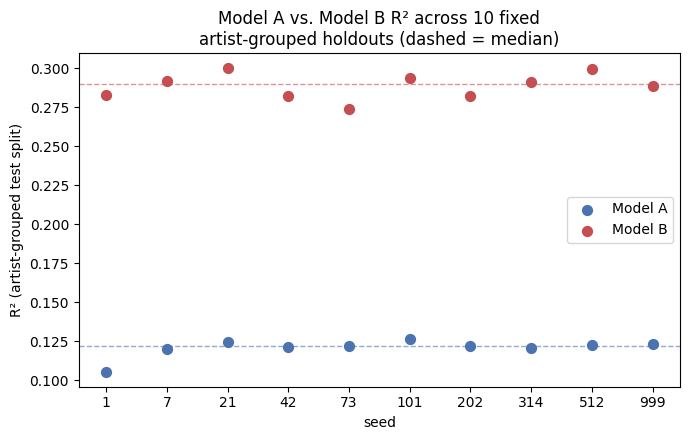

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
seed_labels = [str(s) for s in sweep["seed"]]
x = np.arange(len(seed_labels))
ax.scatter(x, sweep["model_a_r2"], label="Model A", color="#4C72B0", s=50)
ax.scatter(x, sweep["model_b_r2"], label="Model B", color="#C44E52", s=50)
ax.axhline(sweep["model_a_r2"].median(), color="#4C72B0", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(sweep["model_b_r2"].median(), color="#C44E52", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(seed_labels)
ax.set_xlabel("seed")
ax.set_ylabel("R² (artist-grouped test split)")
ax.set_title("Model A vs. Model B R² across 10 fixed\nartist-grouped holdouts (dashed = median)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_model_comparison_grouped_split.png", dpi=150)
plt.show()

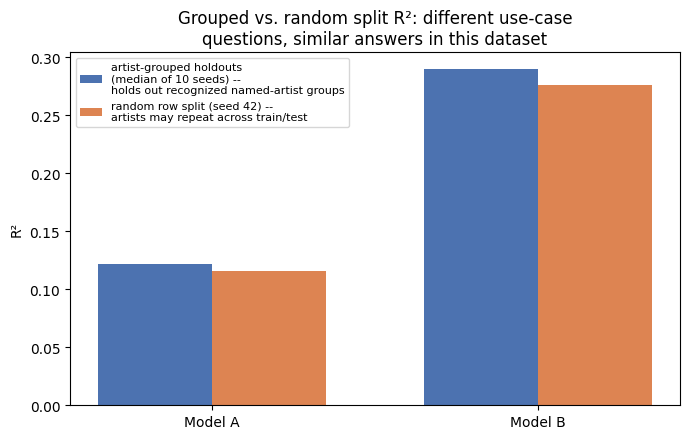

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ["Model A", "Model B"]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [sweep["model_a_r2"].median(), sweep["model_b_r2"].median()],
       width, label="artist-grouped holdouts\n(median of 10 seeds) --\nholds out recognized named-artist groups", color="#4C72B0")
ax.bar(x + width/2, [model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]],
       width, label="random row split (seed 42) --\nartists may repeat across train/test", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("R²")
ax.set_title("Grouped vs. random split R²: different use-case\nquestions, similar answers in this dataset")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_grouped_vs_random_split.png", dpi=150)
plt.show()

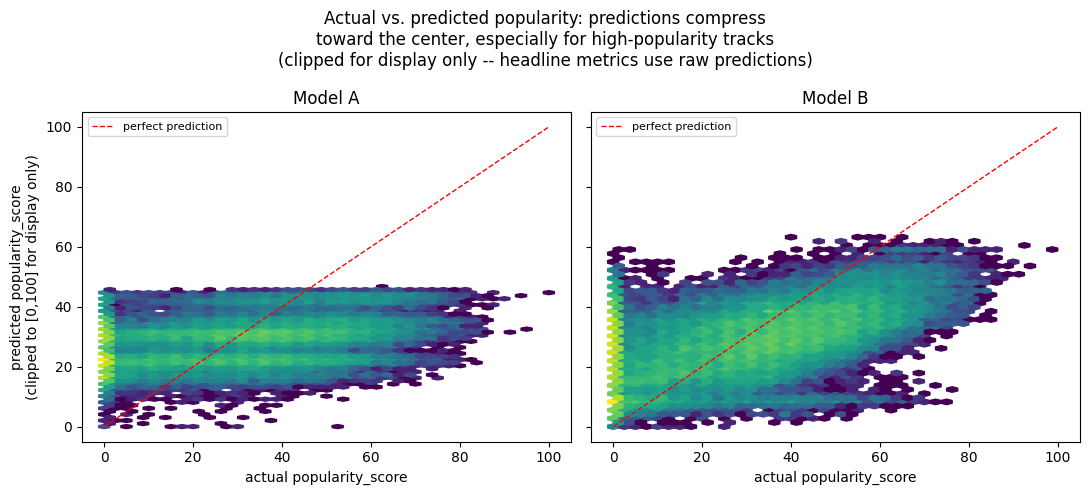

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, res, name in zip(axes, [model_a_g, model_b_g], ["Model A", "Model B"]):
    y_true = res["y_test"]
    y_pred_clipped = M.clip_predictions(res["y_pred"])
    ax.hexbin(y_true, y_pred_clipped, gridsize=40, cmap="viridis", mincnt=1, bins="log")
    ax.plot([0, 100], [0, 100], color="red", linewidth=1, linestyle="--", label="perfect prediction")
    ax.set_xlabel("actual popularity_score")
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("predicted popularity_score\n(clipped to [0,100] for display only)")
fig.suptitle("Actual vs. predicted popularity: predictions compress\ntoward the center, especially for high-popularity tracks\n(clipped for display only -- headline metrics use raw predictions)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_actual_vs_predicted.png", dpi=150)
plt.show()

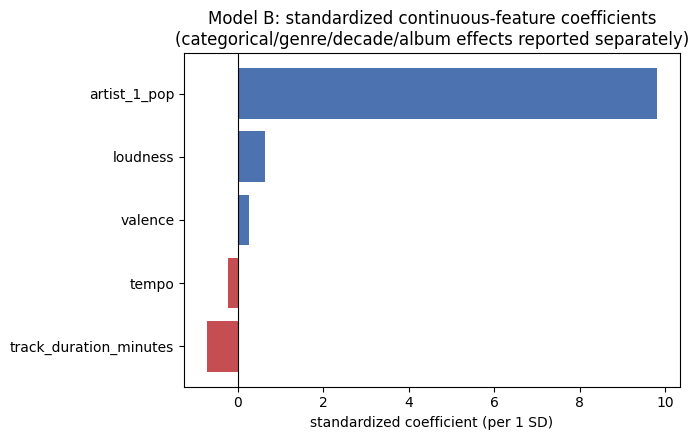

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_coefs = continuous_coefs.sort_values()
colors_c = ["#C44E52" if v < 0 else "#4C72B0" for v in plot_coefs.values]
ax.barh(plot_coefs.index, plot_coefs.values, color=colors_c)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient (per 1 SD)")
ax.set_title("Model B: standardized continuous-feature coefficients\n(categorical/genre/decade/album effects reported separately)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_standardized_coefficients.png", dpi=150)
plt.show()

## 14. Limitations

- **Observational data; no causal claims.** Every association reported here
  is descriptive, evaluated on held-out data.
- **`artist_1` remains an imperfect canonical artist identifier** — it may
  still contain concatenated collaborator names for otherwise-normal-looking
  entries beyond the placeholder labels addressed in §4.
- **Target-range compression (§10)** is a real limit of this linear
  specification on this feature set and dataset — both models substantially
  underpredict the scores of high-popularity tracks, and this analysis does
  not attempt a nonlinear fix (out of scope for this phase).
- **Genre availability is not random** (Phase 2 §15).
- **Release decade is entangled with recency/survivorship/catalog
  composition**, not a pure content attribute.
- **Sampling frame and collection time remain unverified** (Phase 2).
- Grouped-split R² varies modestly across seeds (§6); this analysis does
  not isolate the source of that variation.
- Model performance is modest (R² ≈0.106–0.127 for Model A,
  ≈0.274–0.300 for Model B across grouped seeds).

## 15. Conclusions

- Model A (content/context only) explains a modest, consistent share of
  popularity variation across every evaluation design tried (median R²
  ≈0.122, range 0.106–0.127 across 10 repeated/fixed artist-grouped
  holdouts).
- Model A's predictions compress strongly toward the middle of the
  popularity distribution — both models substantially underpredict the
  scores of high-popularity tracks.
- Model B (+ `artist_1_pop`) consistently outperforms Model A (median R²
  ≈0.290, range 0.274–0.300 across the same 10 holdouts, and similarly
  under a random row split) — its value is not an artifact of a single
  convenient split.
- The random and artist-grouped splits answer different practical
  questions in principle; in this dataset they point to a similar
  conclusion. The artist-grouped split holds out recognized named-artist
  groups, but unidentified/placeholder credits cannot be confirmed to be
  genuinely distinct performers from those in training (§4, §7).
- `artist_1_pop`'s coefficient and predictive value are reported
  descriptively, not causally — it remains conceptually close to the
  outcome.
- Metadata limitations — genre missingness (Phase 2) and placeholder artist
  identities (this phase) — materially affect interpretation.
- No claim is made that content/context characteristics, or artist
  popularity, *cause* track popularity — only that they are associated with
  it, to the degree, and with the caveats, quantified above.